In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

os.makedirs("/workspace/models/ncf", exist_ok=True)
os.makedirs("/workspace/outputs/metrics", exist_ok=True)
os.makedirs("/workspace/outputs/figures", exist_ok=True)

print("TensorFlow:", tf.__version__)
print("CPU:", tf.config.list_physical_devices("CPU"))
print("GPU:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1778061710.874695    4725 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778061710.887939    4725 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778061715.482529    4725 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778061715.485320    4725 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0
CPU: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
GPU: []


E0000 00:00:1778061717.614687    4725 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
def read_single_csv_from_spark_folder(folder):
    files = glob.glob(f"{folder}/part-*.csv")
    if not files:
        raise FileNotFoundError(f"No part csv found in {folder}")
    return pd.read_csv(files[0])

train_df = read_single_csv_from_spark_folder("/workspace/outputs/ncf/train_csv")
test_df = read_single_csv_from_spark_folder("/workspace/outputs/ncf/test_csv")

with open("/workspace/outputs/ncf/ncf_metadata.json", "r", encoding="utf-8") as f:
    metadata = json.load(f)

num_users = int(metadata["num_users"])
num_movies = int(metadata["num_movies"])
genome_feature_dim = int(metadata["genome_feature_dim"])
movie_genome_features = np.load("/workspace/outputs/ncf/movie_genome_features.npy").astype("float32")

train_df.head(), test_df.head(), metadata, movie_genome_features.shape

(   user_idx  movie_idx  label
 0         0         28      1
 1         0         49      1
 2         0        575      1
 3         0        751      0
 4         0        842      0,
    user_idx  movie_idx  label
 0         0        528      1
 1         0        842      0
 2         0       1124      1
 3         0       1528      0
 4         0       3068      1,
 {'num_users': 25943,
  'num_movies': 27099,
  'num_positive_samples': 2000000,
  'negative_sampling_ratio': 1,
  'label_rule': 'rating >= 4.0 => positive',
  'model_input': 'user_idx, movie_idx, label, movie_genome_features[movie_idx]',
  'uses_genome_features': True,
  'genome_feature_dim': 128,
  'matrix_shape': [27099, 128],
  'feature_file': '/workspace/outputs/ncf/movie_genome_features.npy',
  'feature_tags_file': '/workspace/outputs/ncf/genome_feature_tags.csv',
  'feature_selection_strategy': 'Top genome tags by relevance standard deviation over movies used in NCF dataset'},
 (27099, 128))

In [3]:
BATCH_SIZE = 8192

train_ds = tf.data.Dataset.from_tensor_slices((
    {
        "user_idx": train_df["user_idx"].astype("int32").values,
        "movie_idx": train_df["movie_idx"].astype("int32").values,
    },
    train_df["label"].astype("float32").values
)).shuffle(200_000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((
    {
        "user_idx": test_df["user_idx"].astype("int32").values,
        "movie_idx": test_df["movie_idx"].astype("int32").values,
    },
    test_df["label"].astype("float32").values
)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [4]:
from tensorflow.keras import layers, Model

EMBEDDING_DIM = 64
GENOME_PROJECTION_DIM = 64

user_input = layers.Input(shape=(), name="user_idx", dtype=tf.int32)
movie_input = layers.Input(shape=(), name="movie_idx", dtype=tf.int32)

user_embedding = layers.Embedding(
    input_dim=num_users,
    output_dim=EMBEDDING_DIM,
    name="user_embedding"
)(user_input)

movie_embedding = layers.Embedding(
    input_dim=num_movies,
    output_dim=EMBEDDING_DIM,
    name="movie_embedding"
)(movie_input)

genome_embedding = layers.Embedding(
    input_dim=num_movies,
    output_dim=genome_feature_dim,
    weights=[movie_genome_features],
    trainable=False,
    name="movie_genome_features"
)(movie_input)

user_vec = layers.Flatten(name="user_vec")(user_embedding)
movie_vec = layers.Flatten(name="movie_vec")(movie_embedding)
genome_vec = layers.Flatten(name="genome_vec")(genome_embedding)

genome_projection = layers.Dense(GENOME_PROJECTION_DIM, activation="relu", name="genome_projection")(genome_vec)
genome_projection = layers.Dropout(0.2)(genome_projection)

x = layers.Concatenate(name="hybrid_user_movie_genome_concat")([user_vec, movie_vec, genome_projection])
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation="relu")(x)

output = layers.Dense(1, activation="sigmoid", name="preference_probability")(x)

model = Model(inputs=[user_input, movie_input], outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ movie_idx           │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_genome_featu… │ (None, 128)       │  3,468,672 │ movie_idx[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_idx            │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ genome_vec          │ (None, 128)       │          0 │ movie_genome_fea… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 64)        │  1,660,352 │ user_idx[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding     │ (None, 64)        │  1,734,336 │ movie_idx[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ genome_projection   │ (None, 64)        │      8,256 │ genome_vec[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_vec (Flatten)  │ (None, 64)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_vec (Flatten) │ (None, 64)        │          0 │ movie_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ genome_projectio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_user_movie_… │ (None, 192)       │          0 │ user_vec[0][0],   │
│ (Concatenate)       │                   │            │ movie_vec[0][0],  │
│                     │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     24,704 │ hybrid_user_movi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preference_probabi… │ (None, 1)         │         33 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,906,689 (26.35 MB)

 Trainable params: 3,438,017 (13.11 MB)

 Non-trainable params: 3,468,672 (13.23 MB)

In [5]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=2,
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 135s 340ms/step - accuracy: 0.8612 - auc: 0.9318 - loss: 0.3327 - val_accuracy: 0.8825 - val_auc: 0.9488 - val_loss: 0.2831
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 133s 340ms/step - accuracy: 0.8856 - auc: 0.9500 - loss: 0.2785 - val_accuracy: 0.8959 - val_auc: 0.9569 - val_loss: 0.2587
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 135s 344ms/step - accuracy: 0.8949 - auc: 0.9562 - loss: 0.2583 - val_accuracy: 0.9010 - val_auc: 0.9598 - val_loss: 0.2501
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 133s 340ms/step - accuracy: 0.9030 - auc: 0.9614 - loss: 0.2402 - val_accuracy: 0.9100 - val_auc: 0.9651 - val_loss: 0.2315
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 125s 319ms/step - accuracy: 0.9125 - auc: 0.9672 - loss: 0.2187 - val_accuracy: 0.9163 - val_auc: 0.9687 - val_loss: 0.2188
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 139s 356ms/step - accuracy: 0.9193 - auc: 0.9710 - loss: 0.2033 - val_accuracy: 0.9204 - val_auc: 0.9708 - val_loss: 0.2116
Epoch 7/10
391/3

In [6]:
eval_result = model.evaluate(test_ds, return_dict=True)
eval_result

98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9302 - auc: 0.9747 - loss: 0.1982


{'accuracy': 0.930179238319397,
 'auc': 0.9747053384780884,
 'loss': 0.1982422173023224}

In [7]:
model.save("/workspace/models/ncf/ncf_model.keras")

ncf_metrics = {
    "model": "Hybrid Neural Collaborative Filtering with Movie Genome Features",
    "embedding_dim": int(EMBEDDING_DIM),
    "genome_projection_dim": int(GENOME_PROJECTION_DIM),
    "genome_feature_dim": int(genome_feature_dim),
    "uses_genome_features": True,
    "batch_size": int(BATCH_SIZE),
    **{k: float(v) for k, v in eval_result.items()}
}

with open("/workspace/outputs/metrics/ncf_metrics.json", "w", encoding="utf-8") as f:
    json.dump(ncf_metrics, f, ensure_ascii=False, indent=2)

ncf_metrics

{'model': 'Hybrid Neural Collaborative Filtering with Movie Genome Features',
 'embedding_dim': 64,
 'genome_projection_dim': 64,
 'genome_feature_dim': 128,
 'uses_genome_features': True,
 'batch_size': 8192,
 'accuracy': 0.930179238319397,
 'auc': 0.9747053384780884,
 'loss': 0.1982422173023224}

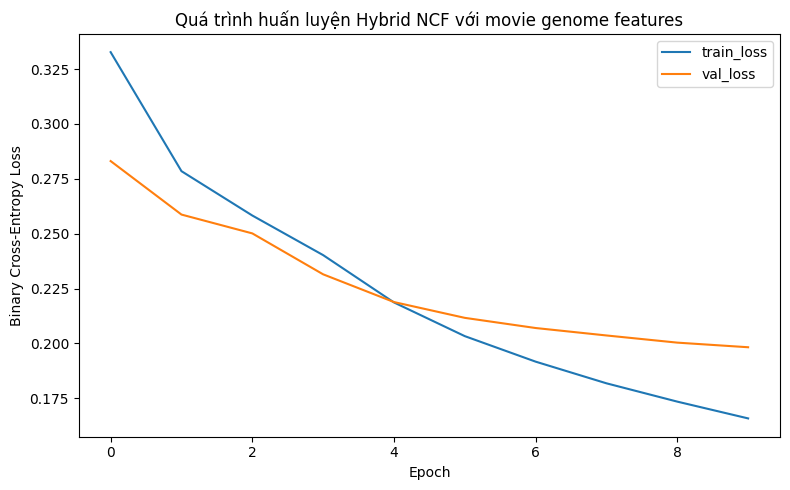

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Quá trình huấn luyện Hybrid NCF với movie genome features")
plt.legend()
plt.tight_layout()
plt.savefig("/workspace/outputs/figures/ncf_training_loss.png", dpi=200)
plt.show()